# 🔍 Unsupervised Learning Project: Customer Segmentation
## MICHEAL OLUWATOBILOBA OMIRIN

**Theory, algorithms, and a real‑world dataset**

Unlike supervised learning (where we have labels), here we only have input features  
and we want to discover hidden patterns, groups, or structures in the data.

## What you will learn
1. The difference between supervised and unsupervised learning  
2. **K‑Means clustering** – how it works, how to choose K  
3. **Hierarchical clustering** – agglomerative approach and dendrograms  
4. **Dimensionality reduction** – PCA (Principal Component Analysis) and t‑SNE  
5. A complete **customer segmentation** project

All code runs in Google Colab with zero setup.


## 1. What is Unsupervised Learning?

In unsupervised learning, we work with **unlabelled data** – no target variable to predict.
The goal is to find natural groupings (clustering) or to compress/visualise data (dimensionality reduction).

**Examples:**
- Market segmentation (grouping customers by behaviour)
- Anomaly detection (fraud, defects)
- Topic modelling (grouping documents)
- Image compression (reducing colours)

In this project we focus on **clustering** – partitioning data into groups (clusters) such that
points in the same group are more similar to each other than to those in other groups.

## 2. The Dataset: Mall Customers

We'll use the classic **Mall Customer Segmentation Data**.
It contains information about customers of a mall:
- `CustomerID` – unique identifier  
- `Gender` – Male / Female  
- `Age` – age of the customer  
- `Annual Income (k$)` – yearly income in thousand dollars  
- `Spending Score (1–100)` – score assigned by the mall based on spending behaviour

**Goal:** Segment customers into distinct groups so the marketing team can
target each group with personalised campaigns.

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
%matplotlib inline

# Download the dataset
url = 'https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv'
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Statistical summary:


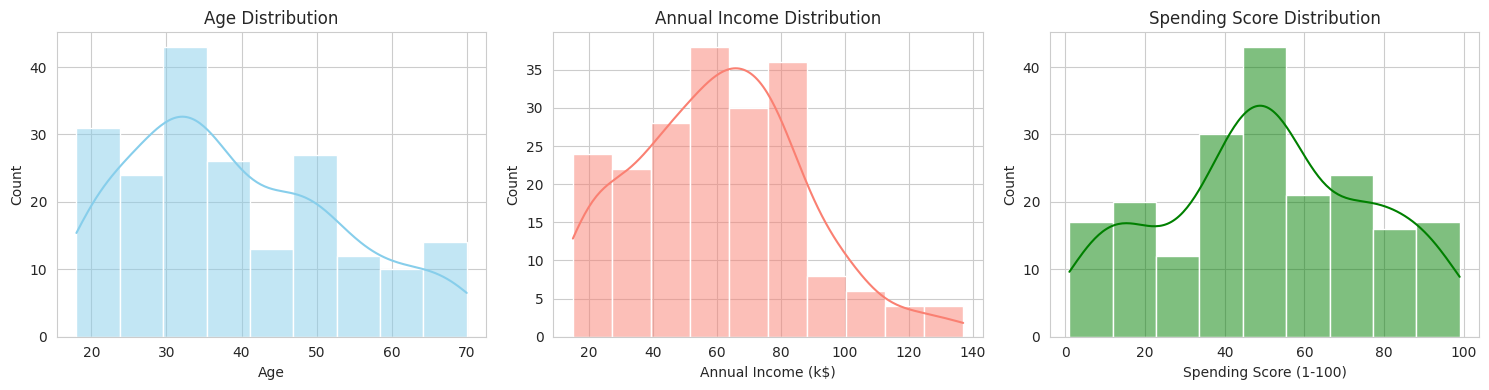

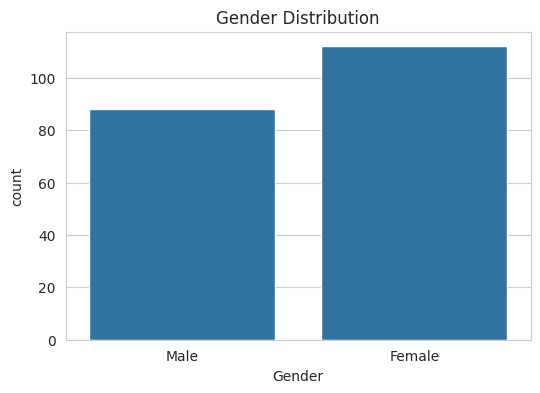

In [6]:
# Exploratory Data Analysis
print("\nData types and missing values:")
df.info()

print("\nStatistical summary:")
df.describe()

# Distribution of features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='salmon')
sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='green')
axes[0].set_title('Age Distribution')
axes[1].set_title('Annual Income Distribution')
axes[2].set_title('Spending Score Distribution')
plt.tight_layout()
plt.show()

# Gender count
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

In [4]:
df = df.rename(columns={'Genre': 'Gender'})
print("Column 'Genre' renamed to 'Gender'.")
display(df.head())

Column 'Genre' renamed to 'Gender'.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


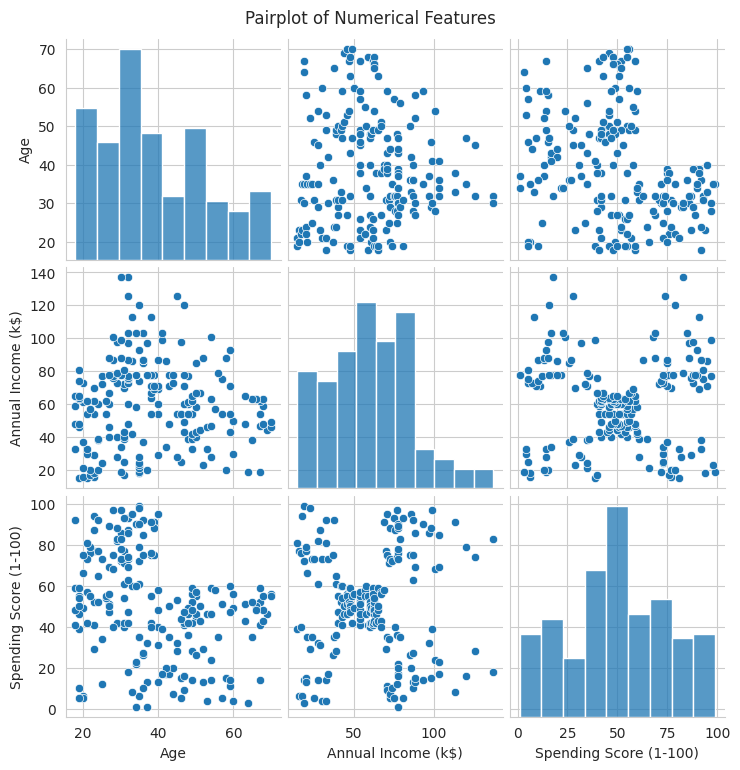

In [7]:
# Pairplot to see relationships
sns.pairplot(df.drop(['CustomerID', 'Gender'], axis=1))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

**Observations:**
- No missing values – clean dataset.
- Most customers are between 20 and 70 years old.
- Income and Spending Score show interesting patterns – likely clusters.

In [8]:
# --- Preprocessing ---
# Select features and standardize them

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

# Standardise (important for distance‑based methods like K‑Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features after scaling (first 5 rows):\n", X_scaled[:5])

Features after scaling (first 5 rows):
 [[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


## 3. K‑Means Clustering

**How it works:**
1. Choose the number of clusters **K**.
2. Randomly initialise K centroids.
3. Assign each point to the nearest centroid.
4. Update centroids to be the mean of assigned points.
5. Repeat steps 3‑4 until convergence.

**How to choose K?**
- **Elbow method:** Plot WCSS for different K. The "elbow" indicates optimal K.
- **Silhouette score:** Measures how similar a point is to its own cluster vs. others.

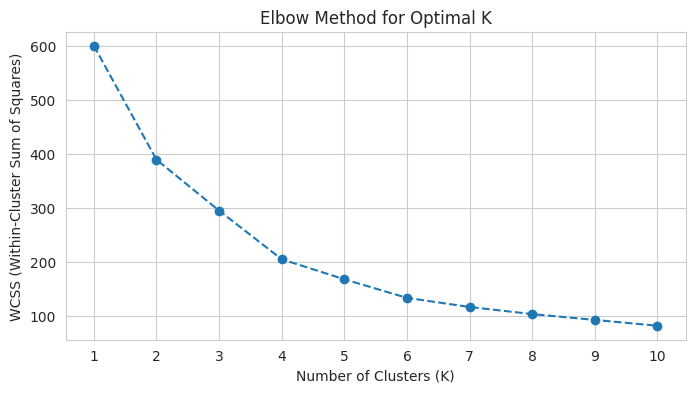

In [9]:
# --- Elbow Method ---
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)   # inertia_ is WCSS

plt.figure(figsize=(8,4))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within‑Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

K=2, Silhouette Score: 0.335
K=3, Silhouette Score: 0.358
K=4, Silhouette Score: 0.404
K=5, Silhouette Score: 0.417
K=6, Silhouette Score: 0.428
K=7, Silhouette Score: 0.417
K=8, Silhouette Score: 0.408
K=9, Silhouette Score: 0.418
K=10, Silhouette Score: 0.407


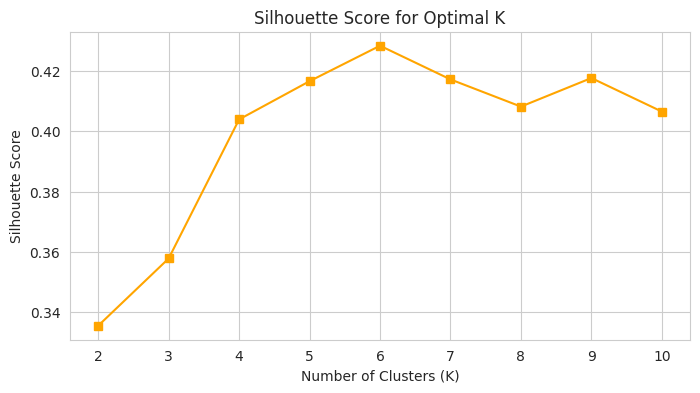

In [10]:
# --- Silhouette Score ---
sil_scores = []
for k in range(2, 11):   # silhouette needs at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"K={k}, Silhouette Score: {sil:.3f}")

plt.figure(figsize=(8,4))
plt.plot(range(2, 11), sil_scores, marker='s', color='orange')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [11]:
# Train final K‑Means model with optimal K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df_kmeans = df.copy()
df_kmeans['Cluster'] = clusters_kmeans

# Cluster sizes
print("K‑Means cluster sizes:")
print(df_kmeans['Cluster'].value_counts().sort_index())

K‑Means cluster sizes:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


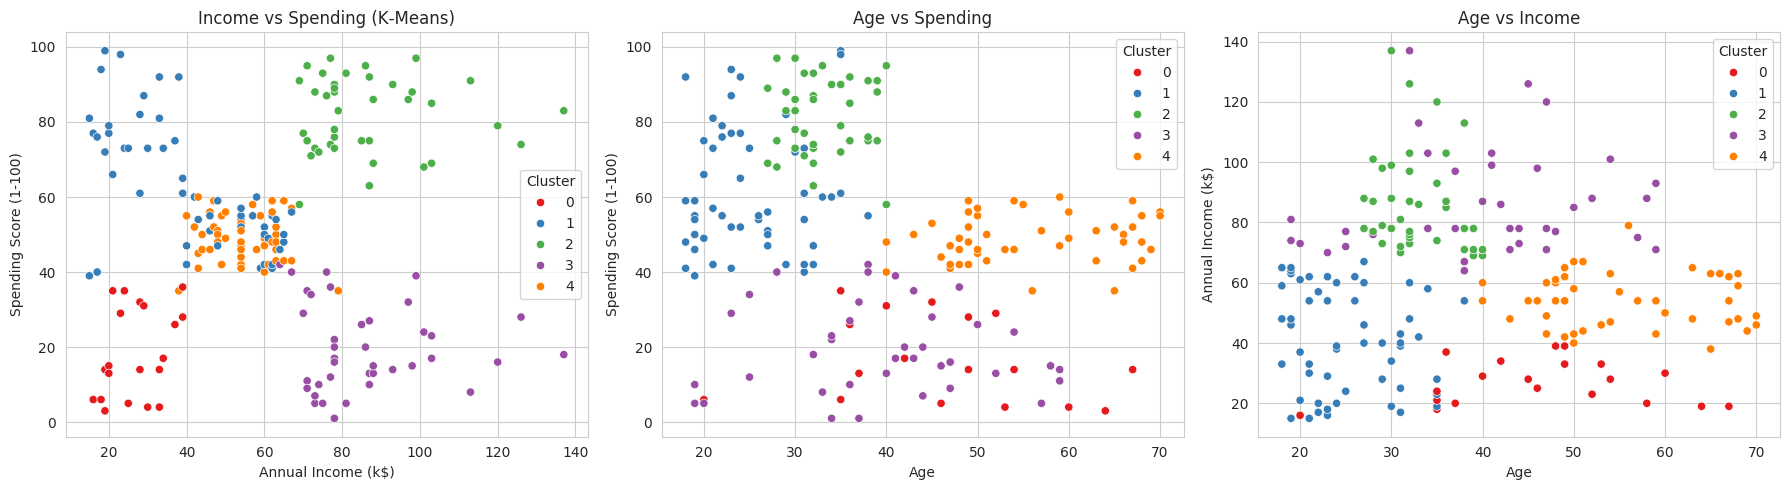

In [12]:
# Visualise clusters (Income vs Spending)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', data=df_kmeans, palette='Set1', ax=axes[0])
axes[0].set_title('Income vs Spending (K‑Means)')
sns.scatterplot(x='Age', y='Spending Score (1-100)',
                hue='Cluster', data=df_kmeans, palette='Set1', ax=axes[1])
axes[1].set_title('Age vs Spending')
sns.scatterplot(x='Age', y='Annual Income (k$)',
                hue='Cluster', data=df_kmeans, palette='Set1', ax=axes[2])
axes[2].set_title('Age vs Income')
plt.tight_layout()
plt.show()

## 4. Hierarchical Clustering

Hierarchical clustering builds a tree of clusters (dendrogram).  
We'll use **agglomerative clustering** with **Ward's linkage**.
The dendrogram helps us choose the number of clusters.

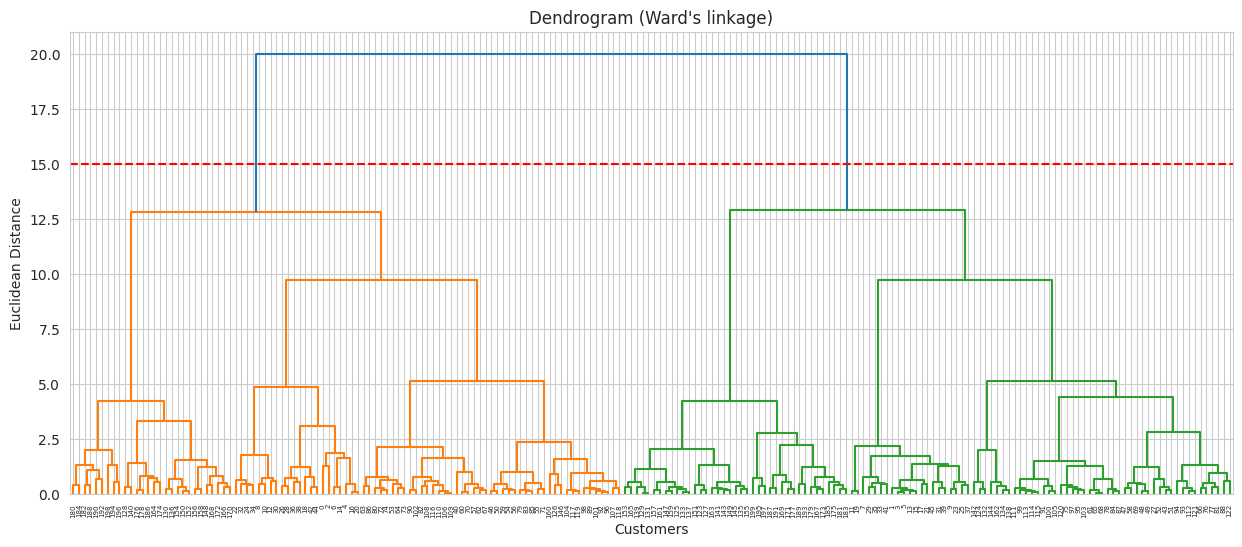

In [13]:
# Dendrogram using Ward's method
plt.figure(figsize=(15, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram (Ward\'s linkage)')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.axhline(y=15, color='red', linestyle='--')
plt.show()

In [14]:
# Agglomerative Clustering with 5 clusters
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
clusters_hc = hc.fit_predict(X_scaled)

df_hc = df.copy()
df_hc['Cluster'] = clusters_hc

print("Hierarchical cluster sizes:")
print(df_hc['Cluster'].value_counts().sort_index())

Hierarchical cluster sizes:
Cluster
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64


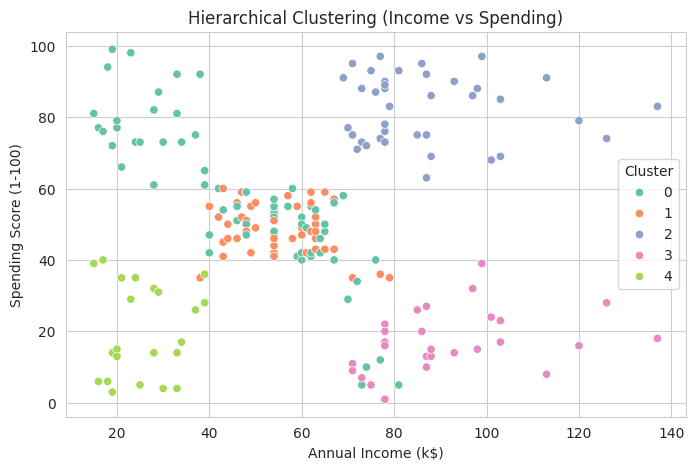

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', data=df_hc, palette='Set2')
plt.title('Hierarchical Clustering (Income vs Spending)')
plt.show()

## 5. Dimensionality Reduction: PCA & t‑SNE

- **PCA:** Finds axes capturing most variance (linear)
- **t‑SNE:** Non‑linear, preserves local similarities (great for visualisation)

Explained variance by PC1 and PC2: [0.44266167 0.33308378]
Total variance captured: 77.57%


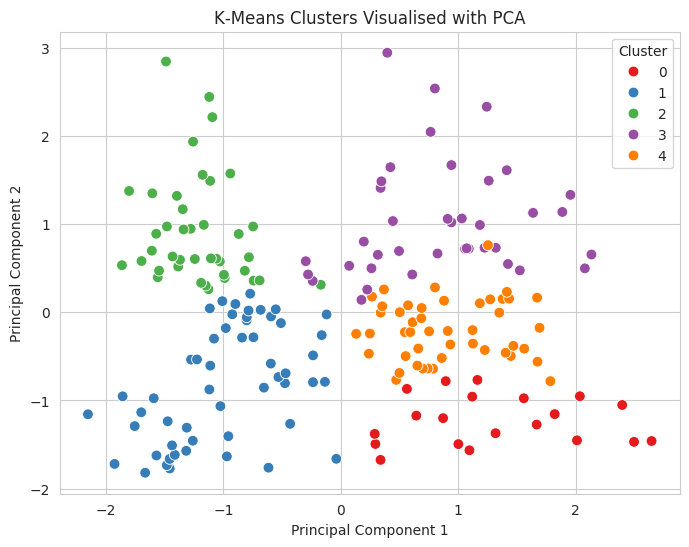

In [16]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance by PC1 and PC2:", pca.explained_variance_ratio_)
print("Total variance captured: {:.2%}".format(sum(pca.explained_variance_ratio_)))

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters_kmeans

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='Set1', s=60)
plt.title('K‑Means Clusters Visualised with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

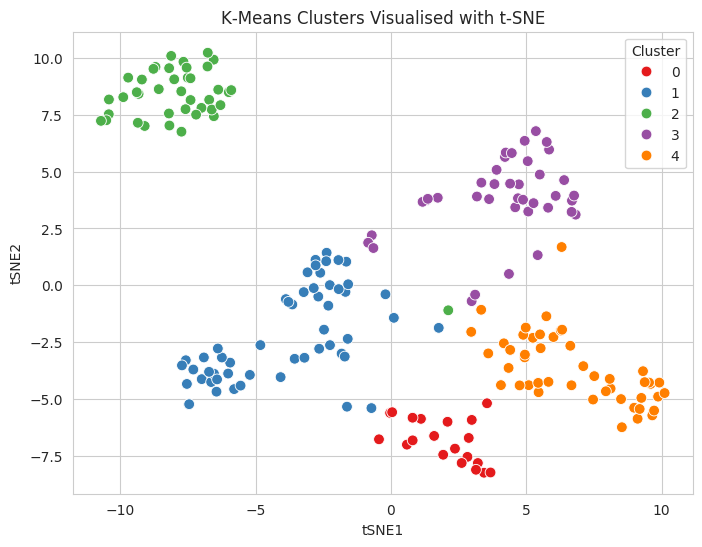

In [17]:
# t‑SNE (may take a few seconds)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=['tSNE1', 'tSNE2'])
df_tsne['Cluster'] = clusters_kmeans

plt.figure(figsize=(8,6))
sns.scatterplot(x='tSNE1', y='tSNE2', hue='Cluster', data=df_tsne, palette='Set1', s=60)
plt.title('K‑Means Clusters Visualised with t‑SNE')
plt.grid(True)
plt.show()

## 6. Cluster Interpretation

Let's understand what each segment represents by looking at average values.

Cluster profiles:
         mean_age  mean_income  mean_spending  count
Cluster                                             
0            46.2         26.8           18.4     20
1            25.2         41.1           62.2     54
2            32.9         86.1           81.5     40
3            39.9         86.1           19.4     39
4            55.6         54.4           48.9     47


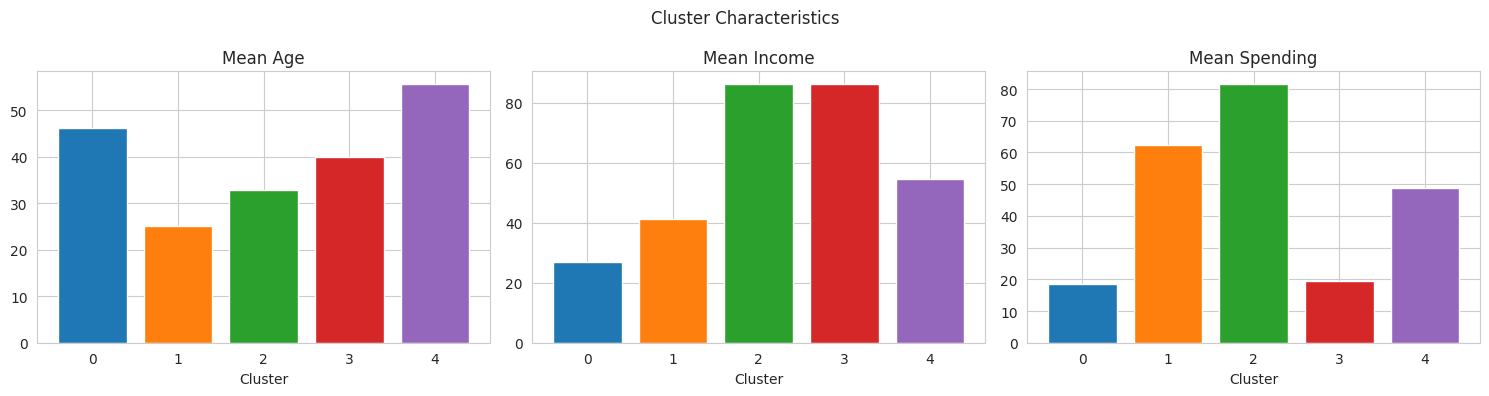

In [18]:
# Analyse clusters based on K‑Means results
cluster_profile = df_kmeans.groupby('Cluster').agg(
    mean_age=('Age', 'mean'),
    mean_income=('Annual Income (k$)', 'mean'),
    mean_spending=('Spending Score (1-100)', 'mean'),
    count=('CustomerID', 'count')
).round(1)

print("Cluster profiles:")
print(cluster_profile)

# Visualise profiles
fig, axes = plt.subplots(1, 3, figsize=(15,4))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, col in enumerate(['mean_age', 'mean_income', 'mean_spending']):
    axes[i].bar(cluster_profile.index, cluster_profile[col], color=colors)
    axes[i].set_title(col.replace('_',' ').title())
    axes[i].set_xlabel('Cluster')
plt.suptitle('Cluster Characteristics')
plt.tight_layout()
plt.show()

## 7. Conclusion and Next Steps

🎉 Well done! You have completed a full unsupervised learning project.

**What you learned:**
- K‑Means and hierarchical clustering algorithms
- How to choose K using elbow method and silhouette score
- Dimensionality reduction with PCA and t‑SNE
- How to interpret clusters for business insights

**To go further:**
- Try **DBSCAN** for density‑based clustering
- Include `Gender` feature (one‑hot encode it)
- Apply clustering on raw non‑scaled data to see why scaling matters

**Thank you for coding along!**

## 8. Assignment Tasks

### Task 1: One-Hot Encode Gender
I'll convert the categorical 'Gender' feature into a numerical format so it can be used in the clustering algorithms.

In [24]:
# One-hot encoding 'Gender'
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# Features including Gender_Male
features_with_gender = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']
X_gender = df_encoded[features_with_gender]

# Scale the new feature set
X_gender_scaled = scaler.fit_transform(X_gender)

print("Encoded features (first 5 rows):")
display(df_encoded[features_with_gender].head())

Encoded features (first 5 rows):


,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


### Task 2: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
DBSCAN is great because it doesn't require us to specify the number of clusters and can find clusters of arbitrary shapes.

DBSCAN cluster sizes (-1 indicates noise/outliers):
Cluster
-1    60
 2    51
 4    32
 3    28
 0    17
 5     7
 1     5
Name: count, dtype: int64


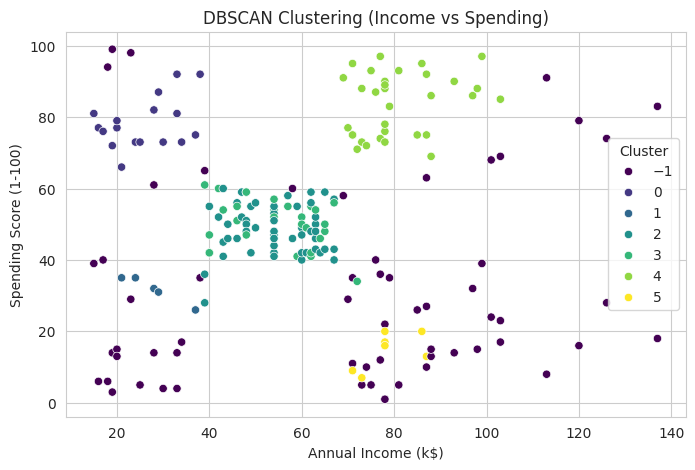

In [21]:
from sklearn.cluster import DBSCAN

# Applying DBSCAN
# eps: maximum distance between two samples for one to be considered as in the neighborhood of the other
# min_samples: number of samples in a neighborhood for a point to be considered a core point
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

# Add to a new dataframe
df_dbscan = df.copy()
df_dbscan['Cluster'] = clusters_dbscan

print("DBSCAN cluster sizes (-1 indicates noise/outliers):")
print(df_dbscan['Cluster'].value_counts())

# Visualise DBSCAN results
plt.figure(figsize=(8,5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', data=df_dbscan, palette='viridis')
plt.title('DBSCAN Clustering (Income vs Spending)')
plt.show()

### Task 3: Clustering on Raw vs Scaled Data
Distance-based algorithms like K-Means are sensitive to the scale of features. Let's see what happens if we don't scale 'Annual Income' (large values) vs 'Age' (small values).

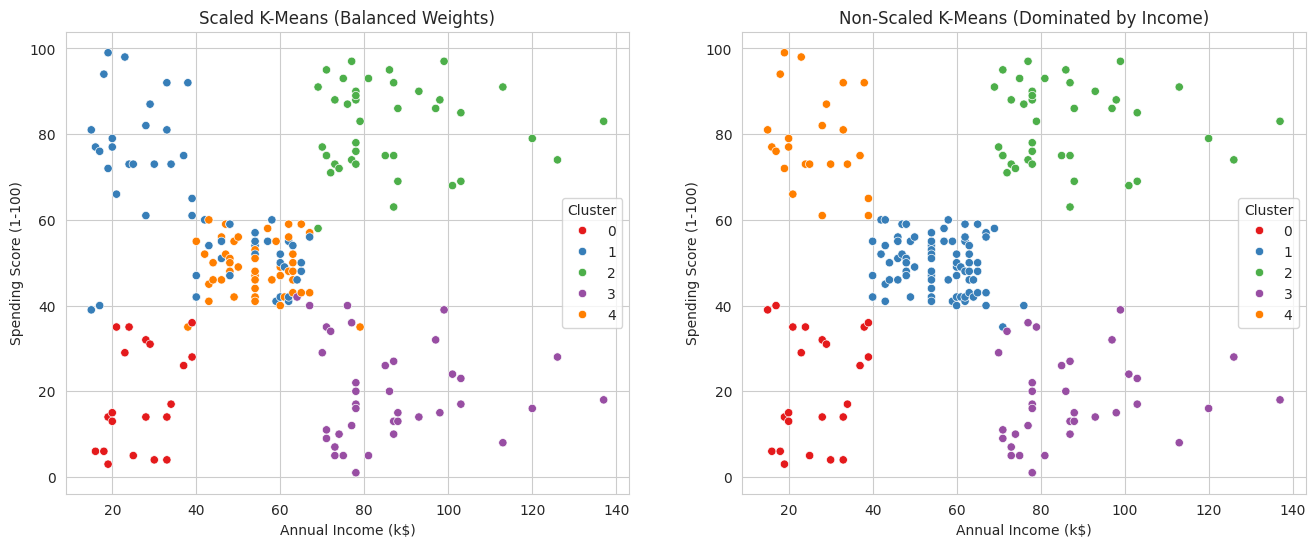

Notice how in the non-scaled version, the clusters are heavily split along the horizontal axis (Income)
because the algorithm treats a '1 unit' difference in income the same as '1 unit' in age.


In [22]:
# K-Means on Raw (Non-Scaled) Data
kmeans_raw = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_raw = kmeans_raw.fit_predict(X)

df_raw = df.copy()
df_raw['Cluster'] = clusters_raw

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', data=df_kmeans, palette='Set1', ax=axes[0])
axes[0].set_title('Scaled K-Means (Balanced Weights)')

sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', data=df_raw, palette='Set1', ax=axes[1])
axes[1].set_title('Non-Scaled K-Means (Dominated by Income)')

plt.show()

print("Notice how in the non-scaled version, the clusters are heavily split along the horizontal axis (Income)")
print("because the algorithm treats a '1 unit' difference in income the same as '1 unit' in age.")

### Comparison of Cluster Profiles (Scaled vs. Raw Data)

We will now compare the mean values of each feature for the two different K-Means results.

In [23]:
# Calculate means for Scaled K-Means
profile_scaled = df_kmeans.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
}).round(1)
profile_scaled.columns = [f'Scaled_{c}' for c in profile_scaled.columns]

# Calculate means for Raw K-Means
profile_raw = df_raw.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
}).round(1)
profile_raw.columns = [f'Raw_{c}' for c in profile_raw.columns]

# Combine into a single table
comparison_table = pd.concat([profile_scaled, profile_raw], axis=1)
display(comparison_table)

print("\nObservation:")
print("In the 'Raw' clusters, notice how the Annual Income means are highly distinct (e.g., 26, 55, 86, 108),")
print("while the Age and Spending scores are often mixed, confirming that the high-magnitude income feature dominated the distance calculation.")

,Scaled_Age,Scaled_Annual Income (k$),Scaled_Spending Score (1-100),Raw_Age,Raw_Annual Income (k$),Raw_Spending Score (1-100)
Cluster,,,,,,
0,46.2,26.8,18.4,45.2,26.3,20.9
1,25.2,41.1,62.2,43.1,55.3,49.6
2,32.9,86.1,81.5,32.7,86.5,82.1
3,39.9,86.1,19.4,40.7,87.8,17.6
4,55.6,54.4,48.9,25.5,26.3,78.6



Observation:
In the 'Raw' clusters, notice how the Annual Income means are highly distinct (e.g., 26, 55, 86, 108),
while the Age and Spending scores are often mixed, confirming that the high-magnitude income feature dominated the distance calculation.


### Visualizing Centroid Differences

We will plot the centroids (mean values) for both models. This visual comparison highlights how scaling prevents one feature from dominating the geometric center of the clusters.

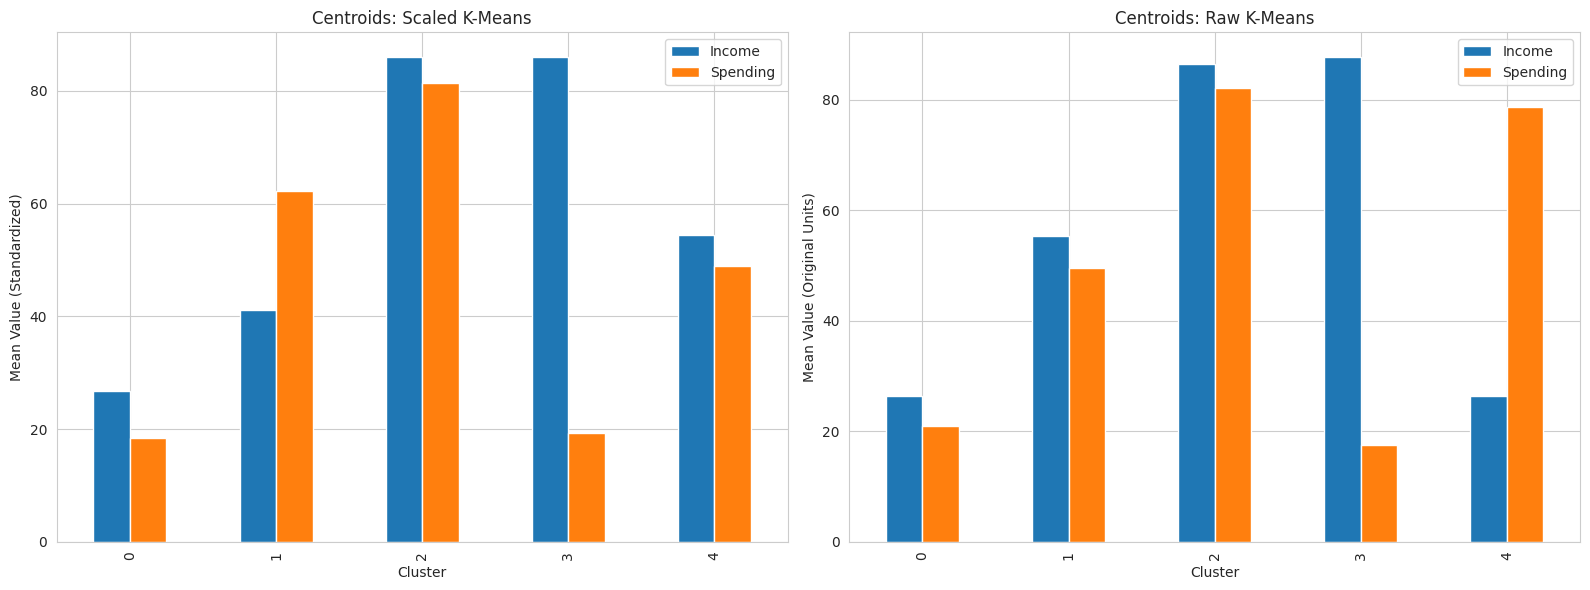

In [25]:
# Prepare data for centroid visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scaled Centroids Plot
profile_scaled[['Scaled_Annual Income (k$)', 'Scaled_Spending Score (1-100)']].plot(kind='bar', ax=ax1)
ax1.set_title('Centroids: Scaled K-Means')
ax1.set_ylabel('Mean Value (Standardized)')
ax1.set_xlabel('Cluster')
ax1.legend(['Income', 'Spending'])

# Raw Centroids Plot
profile_raw[['Raw_Annual Income (k$)', 'Raw_Spending Score (1-100)']].plot(kind='bar', ax=ax2)
ax2.set_title('Centroids: Raw K-Means')
ax2.set_ylabel('Mean Value (Original Units)')
ax2.set_xlabel('Cluster')
ax2.legend(['Income', 'Spending'])

plt.tight_layout()
plt.show()

### PCA-based Overlap Comparison (Scaled vs Raw)
We use PCA to project the multidimensional clusters into 2D space to observe how distinct the segments truly are.

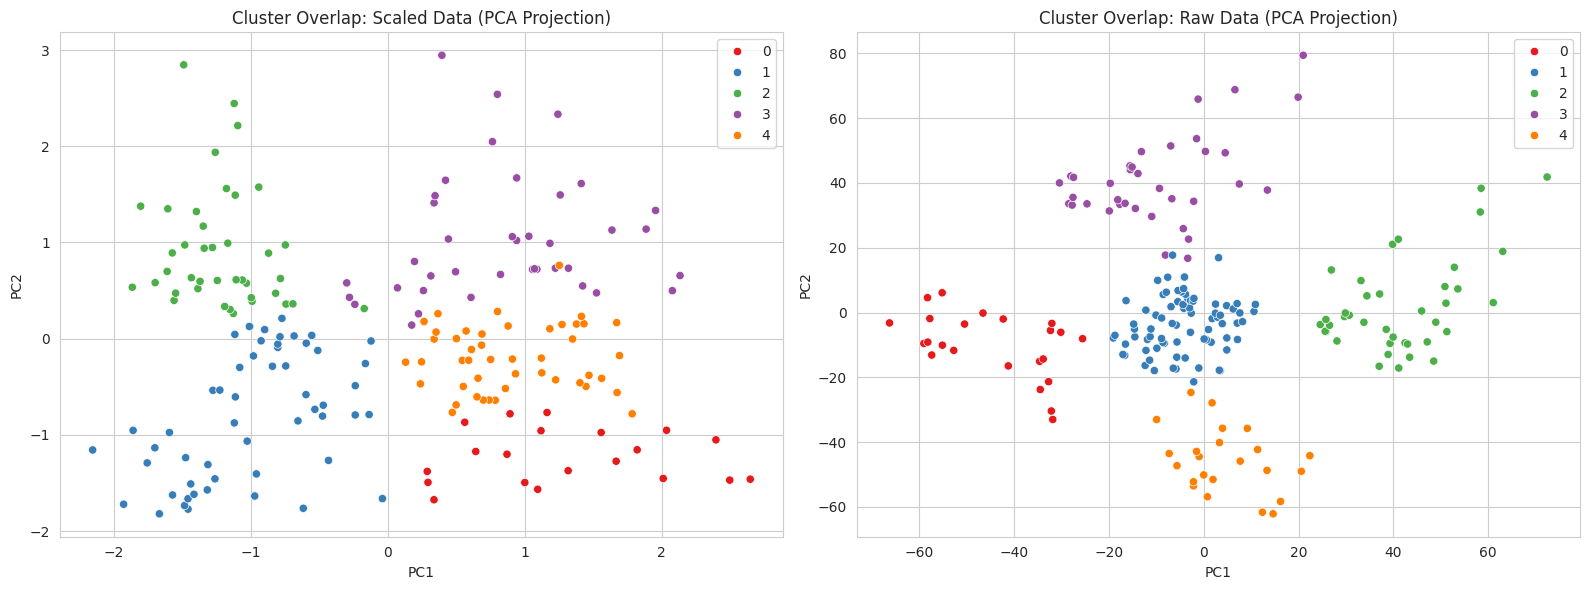

In [26]:
from sklearn.decomposition import PCA

# Perform PCA on Scaled Data
pca_scaled = PCA(n_components=2)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

# Perform PCA on Raw Data
pca_raw = PCA(n_components=2)
X_pca_raw = pca_raw.fit_transform(X)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scaled Plot
sns.scatterplot(x=X_pca_scaled[:, 0], y=X_pca_scaled[:, 1], hue=clusters_kmeans, palette='Set1', ax=axes[0])
axes[0].set_title('Cluster Overlap: Scaled Data (PCA Projection)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Raw Plot
sns.scatterplot(x=X_pca_raw[:, 0], y=X_pca_raw[:, 1], hue=clusters_raw, palette='Set1', ax=axes[1])
axes[1].set_title('Cluster Overlap: Raw Data (PCA Projection)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()